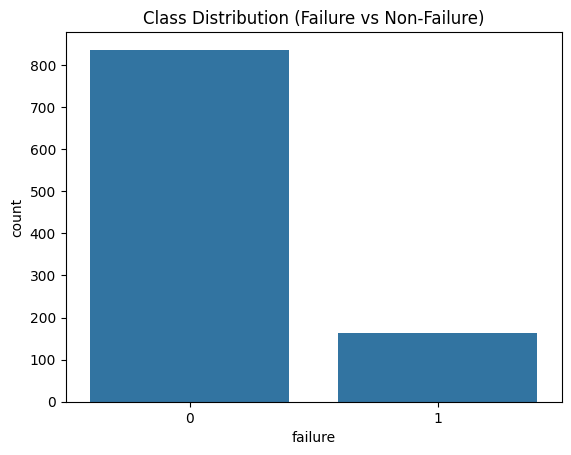

Test Accuracy: 0.69

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.84      0.81       158
           1       0.19      0.14      0.16        42

    accuracy                           0.69       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.66      0.69      0.68       200

Confusion Matrix:
 [[133  25]
 [ 36   6]]


In [2]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Generate Synthetic Data
np.random.seed(42)
n_samples = 1000
data = {
    'temperature': np.random.normal(loc=70, scale=10, size=n_samples),
    'pressure': np.random.normal(loc=30, scale=5, size=n_samples),
    'vibration': np.random.normal(loc=0.5, scale=0.2, size=n_samples),
    'current': np.random.normal(loc=5, scale=1.5, size=n_samples),
    'humidity': np.random.normal(loc=45, scale=10, size=n_samples),
    'failure': np.random.choice([0, 1], size=n_samples, p=[0.85, 0.15])  # 0: no failure, 1: failure
}
df = pd.DataFrame(data)

# Visualize class distribution (Optional)
sns.countplot(x='failure', data=df)
plt.title("Class Distribution (Failure vs Non-Failure)")
plt.show()

# Step 3: Split Features and Target
X = df.drop('failure', axis=1)
y = df['failure']

# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 6: Handle Imbalanced Data with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# Step 7: Train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

# Step 8: Predictions and Evaluation
y_pred = rf_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=1))

# Optional: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
